In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import seaborn as sns
import contextily as cx
from libpysal import weights
import matplotlib.pyplot as plt

from esda.moran import Moran, Moran_Local
from splot.esda import moran_scatterplot

In [3]:
hex_gdf = gpd.read_file("preprocessed data/hex_listing_aggregates_epsg25832.geojson")

hex_gdf.head()
hex_gdf.crs
hex_gdf.columns

Index(['h3_id', 'listing_count', 'median_price', 'mean_price', 'min_price',
       'max_price', 'accommodates_mean', 'accommodates_median',
       'bedrooms_mean', 'bedrooms_median', 'beds_mean', 'beds_median',
       'bathrooms_mean', 'bathrooms_median', 'geometry'],
      dtype='str')

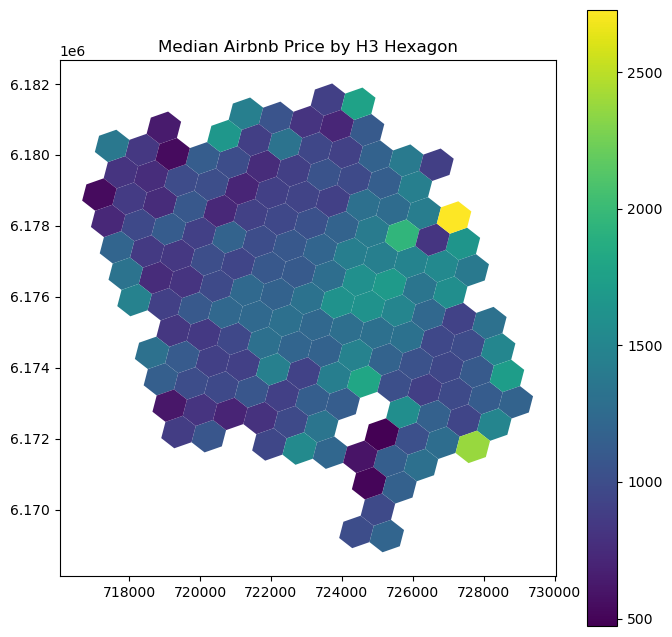

In [4]:
hex_gdf.plot(column="median_price", legend=True, figsize=(8, 8))
plt.title("Median Airbnb Price by H3 Hexagon")
plt.show()

In [5]:
# Queen contiguity weights
w_queen = weights.Queen.from_dataframe(hex_gdf)
w_queen.transform = "r"

print("Number of hexes:", w_queen.n)
print("Average neighbours:", w_queen.mean_neighbors)
print("Islands:", w_queen.islands)

Number of hexes: 162
Average neighbours: 5.222222222222222
Islands: []


C:\Users\kubic\AppData\Local\Temp\ipykernel_17800\1586352421.py:2: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w_queen = weights.Queen.from_dataframe(hex_gdf)


In [7]:
# Number of neighbours for each hexagon
neighbor_counts = [len(neigh) for neigh in w_queen.neighbors.values()]

print("Minimum neighbours:", min(neighbor_counts))
print("Maximum neighbours:", max(neighbor_counts))

Minimum neighbours: 2
Maximum neighbours: 6


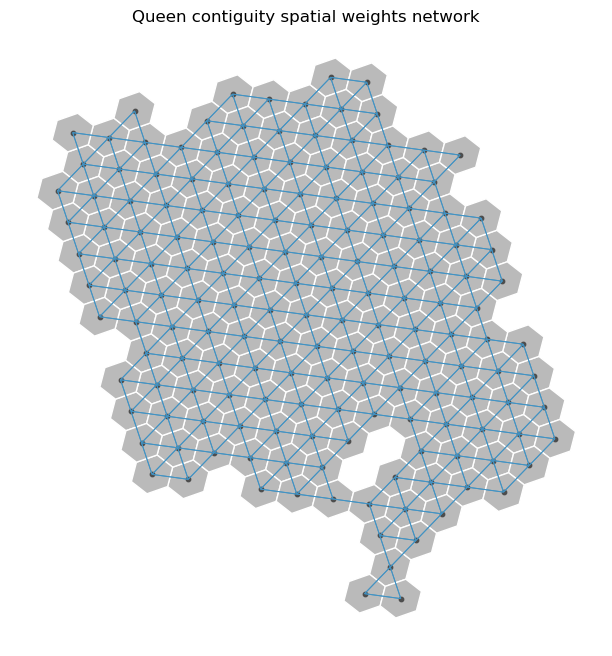

In [6]:
from splot.libpysal import plot_spatial_weights

fig, ax = plt.subplots(figsize=(8,8))

hex_gdf.plot(
    facecolor="lightgrey",
    edgecolor="white",
    linewidth=0.5,
    ax=ax
)

plot_spatial_weights(
    w_queen,
    hex_gdf,
    ax=ax
)

ax.set_title("Queen contiguity spatial weights network")
ax.set_axis_off()

plt.show()

## Global Morens I

In [5]:
y = hex_gdf["median_price"].values

moran_queen = Moran(y, w_queen, permutations=999)

print("Moran's I:", moran_queen.I)
print("p-value:", moran_queen.p_sim)

Moran's I: 0.329956514875096
p-value: 0.001


✅ Interpretation (what it means)
Moran’s I = 0.33 → moderately strong positive spatial autocorrelation
p-value = 0.001 → highly statistically significant

👉 So:

Airbnb prices in Copenhagen are not randomly distributed — they are spatially clustered.

More specifically:

High-price hexes tend to be near other high-price hexes
Low-price hexes tend to be near other low-price hexes

## Local Morens I (LISA)

In [6]:
lisa = Moran_Local(y, w_queen)
hex_gdf["lisa_cluster"] = lisa.q
hex_gdf["lisa_p"] = lisa.p_sim
hex_gdf[["median_price", "lisa_cluster", "lisa_p"]].head()

,median_price,lisa_cluster,lisa_p
0,1223.0,1,0.092
1,1035.0,3,0.261
2,1201.5,1,0.219
3,1170.0,1,0.161
4,1201.5,1,0.334


Filter significant clusters 

In [7]:
hex_gdf["significant"] = hex_gdf["lisa_p"] < 0.05

hex_gdf["cluster"] = 0
hex_gdf.loc[hex_gdf["significant"], "cluster"] = hex_gdf["lisa_cluster"]

In [8]:
# Checking how many significant clusters we have
hex_gdf["significant"].sum()

np.int64(47)

In [9]:
hex_gdf["cluster"].value_counts()

cluster
0    115
3     24
1     17
4      4
2      2
Name: count, dtype: int64

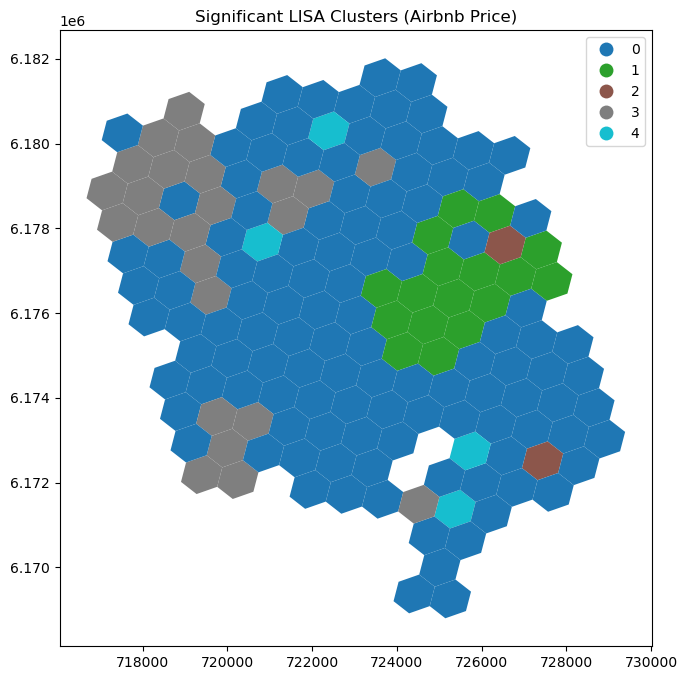

In [10]:
fig, ax = plt.subplots(figsize=(8,8))

hex_gdf.plot(column="cluster",
             categorical=True,
             legend=True,
             ax=ax)

plt.title("Significant LISA Clusters (Airbnb Price)")
plt.show()

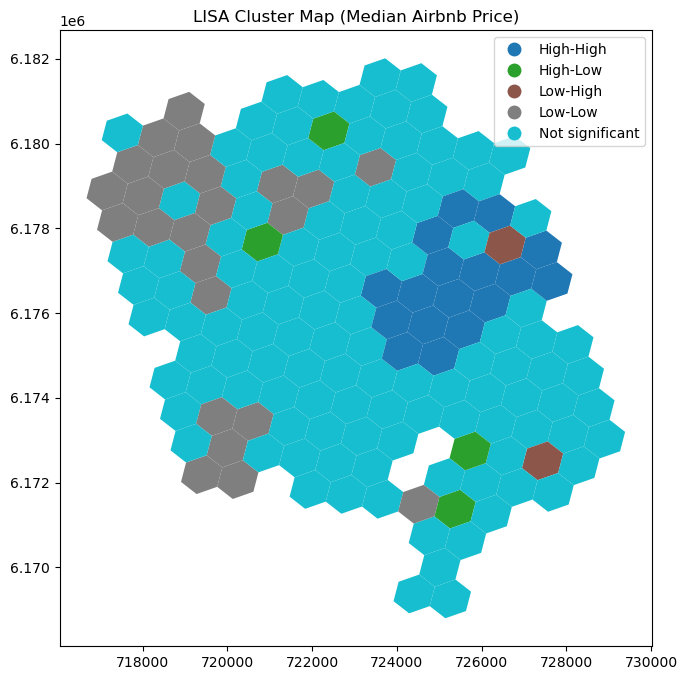

In [11]:
# Map numeric codes to labels
labels = {
    0: "Not significant",
    1: "High-High",
    2: "Low-High",
    3: "Low-Low",
    4: "High-Low"
}

hex_gdf["cluster_label"] = hex_gdf["cluster"].map(labels)

fig, ax = plt.subplots(figsize=(8,8))

hex_gdf.plot(column="cluster_label",
             categorical=True,
             legend=True,
             ax=ax)

plt.title("LISA Cluster Map (Median Airbnb Price)")
plt.show()

Significance map

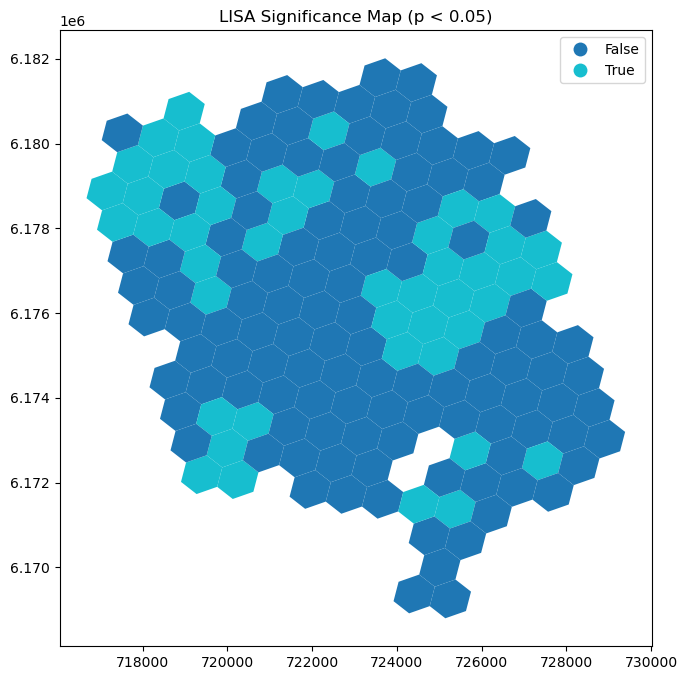

In [12]:
fig, ax = plt.subplots(figsize=(8,8))

hex_gdf.plot(column="significant",
             categorical=True,
             legend=True,
             ax=ax)

plt.title("LISA Significance Map (p < 0.05)")
plt.show()

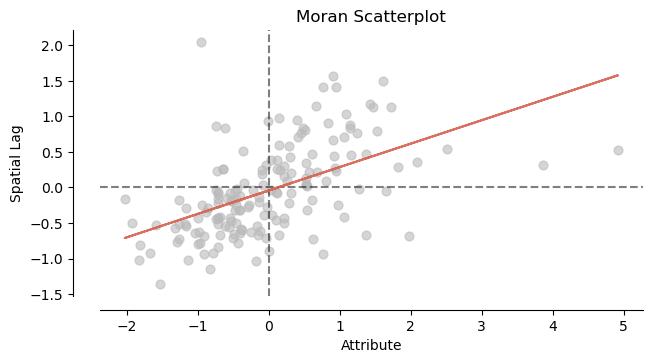

In [13]:
moran_scatterplot(lisa)
plt.title("Moran Scatterplot")
plt.show()

🔥 High-High clusters (green)
Clear cluster in one main area
This is your Airbnb price hotspot
Likely:
city center
tourist-heavy zones
high-demand neighborhoods

👉 Interpretation:

Expensive listings are spatially concentrated, forming a clear high-value core.

❄️ Low-Low clusters (grey)
Found mostly on the edges / periphery
These are low-price clusters

👉 Interpretation:

Lower-priced listings cluster in less central or less attractive areas.

⚠️ Outliers (HL / LH)
Only 6 total → very few
These are:
unusual listings
local anomalies

👉 Interpretation:

The spatial structure is relatively consistent, with only a few localized deviations.

🎯 3. What this means overall (connect to Moran’s I)

You now have:

Global Moran’s I = 0.33 (significant)
LISA clusters clearly visible

👉 This is the key narrative:

Airbnb prices in Copenhagen exhibit both global clustering and localized spatial structures, with distinct hotspots and coldspots.

✍️ 4. Write this in your report (use this — it’s strong)
Local Moran’s I results

Local Moran’s I analysis identified 46 statistically significant hexagons (p < 0.05), representing approximately 28% of the study area. Among these, 18 hexagons form high-high (HH) clusters, indicating hotspots of high Airbnb prices, while 22 hexagons form low-low (LL) clusters, representing coldspots of lower prices.

The HH clusters are spatially concentrated in a central area of the city, suggesting a strong geographic core of high-priced listings, likely associated with high-demand or tourist-oriented neighbourhoods. In contrast, LL clusters are primarily located in peripheral areas, indicating lower-priced listings outside the central zone.

Only a small number of spatial outliers (HL and LH) are observed, suggesting that the overall spatial structure is relatively consistent with limited local deviations.

KNN

In [14]:
w_knn = weights.KNN.from_dataframe(hex_gdf, k=6)
w_knn.transform = "r"

print("KNN neighbours:", w_knn.mean_neighbors)
print("Islands:", w_knn.islands)

KNN neighbours: 6.0
Islands: []


In [15]:
moran_knn = Moran(y, w_knn, permutations=999)

print("KNN Moran's I:", moran_knn.I)
print("KNN p-value:", moran_knn.p_sim)

KNN Moran's I: 0.30873946799125207
KNN p-value: 0.001


👉 results are almost identical → no need to plot all again

In [ ]:
# Save LISA columns for clustering notebook
out = hex_gdf[["h3_id", "lisa_cluster", "lisa_p", "cluster_label"]].rename(
    columns={"cluster_label": "lisa_label"}
)
out.to_parquet("preprocessed data/hex_with_lisa.parquet", index=False)
print("hex_with_lisa.parquet saved")